# Traffic Prediction with Graph WaveNet (PEMS-BAY)
Inspired by https://www.kaggle.com/code/yizhongchao/graph-wavenet-on-pems-bay

In [5]:
import os
import math
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F

from dataclasses import dataclass

# Reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# PEMS-BAY: sampled every 5 minutes
STEP_MINUTES = 5

# Forecast setting
INPUT_LEN = 12   # past 12 * 5min = 60 minutes
HORIZON   = 12   # predict next 12 * 5min = 60 minutes

BATCH_SIZE = 64
EPOCHS = 5        # keep it small for class demo
LR = 1e-3

DEVICE: cpu


## Data Loading

In [6]:
def load_pickle(pickle_file):
    with open(pickle_file, "rb") as f:
        try:
            return pickle.load(f)
        except UnicodeDecodeError:
            f.seek(0)
            return pickle.load(f, encoding="latin1")

DATA_DIR = "/content"

H5_PATH  = os.path.join(DATA_DIR, "pems-bay.h5")
ADJ_PATH = os.path.join(DATA_DIR, "adj_mx_bay.pkl")

# Load speed time series: shape (T, N)
df = pd.read_hdf(H5_PATH)
print("df shape:", df.shape)
print("time range:", df.index.min(), "->", df.index.max())

speed      = df.values.astype(np.float32)   # (T, N)
timestamps = df.index                        # datetime index

# Load adjacency pkl: (sensor_ids, sensor_id_to_ind, adj_mx)
sensor_ids, sensor_id_to_ind, adj_mx = load_pickle(ADJ_PATH)

print("num sensors:", len(sensor_ids))
print("adj shape:", adj_mx.shape)

df shape: (52116, 325)
time range: 2017-01-01 00:00:00 -> 2017-06-30 23:55:00
num sensors: 325
adj shape: (325, 325)


## Preprocessing

In [7]:
class StandardScaler:
    def __init__(self, mean, std):
        self.mean = mean
        self.std  = std if std > 1e-6 else 1.0

    def transform(self, data):
        return (data - self.mean) / self.std

    def inverse_transform(self, data):
        return (data * self.std) + self.mean


def make_windows(data_2d, input_len=12, horizon=12):
    """
    data_2d : (T, N)
    returns  : X (S, input_len, N, 1),  Y (S, horizon, N, 1)
    """
    T, N = data_2d.shape
    X, Y = [], []
    for t in range(input_len, T - horizon + 1):
        X.append(data_2d[t - input_len : t,      :, None])   # (input_len, N, 1)
        Y.append(data_2d[t             : t + horizon, :, None]) # (horizon,   N, 1)
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)


# Time-based split (70 / 10 / 20)
T = speed.shape[0]
train_end = int(T * 0.7)
val_end   = int(T * 0.8)

train_raw = speed[:train_end]
val_raw   = speed[train_end:val_end]
test_raw  = speed[val_end:]

# Fit scaler on TRAINING data only
scaler = StandardScaler(mean=train_raw.mean(), std=train_raw.std())

train_norm = scaler.transform(train_raw)
val_norm   = scaler.transform(val_raw)
test_norm  = scaler.transform(test_raw)

X_train, Y_train = make_windows(train_norm, INPUT_LEN, HORIZON)
X_val,   Y_val   = make_windows(val_norm,   INPUT_LEN, HORIZON)
X_test,  Y_test  = make_windows(test_norm,  INPUT_LEN, HORIZON)

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape,   "Y_val  :", Y_val.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)

X_train: (36458, 12, 325, 1) Y_train: (36458, 12, 325, 1)
X_val  : (5188, 12, 325, 1) Y_val  : (5188, 12, 325, 1)
X_test : (10401, 12, 325, 1) Y_test : (10401, 12, 325, 1)


## Graph Adjacency

In [8]:
def sym_adj(adj):
    """Symmetric normalisation: D^{-1/2} A D^{-1/2}"""
    adj = np.array(adj, dtype=np.float32)
    rowsum = adj.sum(axis=1)
    d_inv_sqrt = np.power(rowsum, -0.5, where=rowsum > 0, out=np.zeros_like(rowsum))
    D = np.diag(d_inv_sqrt)
    return D @ adj @ D


A        = sym_adj(adj_mx)
A_torch  = torch.tensor(A, dtype=torch.float32, device=DEVICE)
SUPPORTS = [A_torch]

## Loss Functions

In [9]:
def masked_mae(pred, real, null_val=0.0):
    mask = (real != null_val).float()
    mask = mask / (mask.mean() + 1e-6)
    return (torch.abs(pred - real) * mask).mean()


def masked_rmse(pred, real, null_val=0.0):
    mask = (real != null_val).float()
    mask = mask / (mask.mean() + 1e-6)
    return torch.sqrt(((pred - real) ** 2 * mask).mean() + 1e-6)


def masked_mape(pred, real, null_val=0.0):
    mask = (real != null_val).float()
    mask = mask / (mask.mean() + 1e-6)
    return (torch.abs((pred - real) / (real.abs() + 1e-6)) * mask).mean()

## Model: Graph WaveNet (lite)

### Bug fixes applied:
1. **`GCN.mlp` input channels** – changed from `(K+1)*c_in` to `(len(supports)*K + 1)*c_in` so the channel count always matches the actual concatenated tensor, regardless of how many support matrices are used.
2. **Loop variable naming** – renamed `gconv → gate_conv` inside the main `forward` loop to eliminate the name collision with `gcn` (the graph conv module), making the code unambiguous.
3. **`sym_adj` safe power** – `np.power` now uses `out=` to avoid NaN on zero-degree nodes instead of a separate `np.isfinite` patch-up.

In [10]:
class NConv(nn.Module):
    """Graph mixing: X' = A X  (applied per channel)."""
    def forward(self, x, A):
        # x: (B, C, N, T)   A: (N, N)
        return torch.einsum("bcnt,nm->bcmt", x, A)


class GCN(nn.Module):
    """
    Multi-hop graph mixing (order K) per support matrix.

    FIX: mlp input size = (num_supports * K + 1) * c_in
         so it correctly handles any number of supports.
         Previously hardcoded (K+1)*c_in assumed only 1 support.
    """
    def __init__(self, c_in, c_out, K=2, num_supports=1):
        super().__init__()
        self.nconv  = NConv()
        self.K      = K
        # 1 (identity) + K hops per support
        total_in    = (num_supports * K + 1) * c_in
        self.mlp    = nn.Conv2d(total_in, c_out, kernel_size=(1, 1))

    def forward(self, x, supports):
        out = [x]                       # hop-0: identity
        for A in supports:
            xk = x
            for _ in range(self.K):     # K hops
                xk = self.nconv(xk, A)
                out.append(xk)
        h = torch.cat(out, dim=1)       # (B, total_in, N, T)
        return self.mlp(h)


class GraphWaveNetLite(nn.Module):
    """
    Minimal GWNet-like model:
      - temporal gated conv (tanh * sigmoid, WaveNet-style)
      - graph mixing (GCN)
      - residual + skip connections
      - final 1x1 conv head outputs HORIZON steps

    FIX: loop variable renamed gate_conv (was 'gconv') to avoid
         shadowing the graph-conv module variable 'gcn'.
    """
    def __init__(self, num_nodes, in_dim=1, residual_channels=32,
                 skip_channels=64, end_channels=128,
                 kernel_size=2, blocks=2, layers=2, dropout=0.2):
        super().__init__()
        self.num_nodes = num_nodes
        self.dropout   = dropout

        self.start_conv = nn.Conv2d(in_dim, residual_channels, kernel_size=(1, 1))

        self.filter_convs   = nn.ModuleList()
        self.gate_convs     = nn.ModuleList()
        self.residual_convs = nn.ModuleList()
        self.skip_convs     = nn.ModuleList()
        self.gconvs         = nn.ModuleList()
        self.bns            = nn.ModuleList()

        self.receptive_field = 1
        dilation = 1
        for _ in range(blocks):
            for _ in range(layers):
                self.filter_convs.append(
                    nn.Conv2d(residual_channels, residual_channels, (1, kernel_size), dilation=(1, dilation))
                )
                self.gate_convs.append(
                    nn.Conv2d(residual_channels, residual_channels, (1, kernel_size), dilation=(1, dilation))
                )
                self.residual_convs.append(nn.Conv2d(residual_channels, residual_channels, (1, 1)))
                self.skip_convs.append(nn.Conv2d(residual_channels, skip_channels, (1, 1)))
                self.gconvs.append(
                    GCN(residual_channels, residual_channels, K=2, num_supports=len(SUPPORTS))
                )
                self.bns.append(nn.BatchNorm2d(residual_channels))

                self.receptive_field += (kernel_size - 1) * dilation
                dilation *= 2

        self.end_conv_1 = nn.Conv2d(skip_channels,   end_channels, kernel_size=(1, 1))
        self.end_conv_2 = nn.Conv2d(end_channels,    HORIZON,      kernel_size=(1, 1))

    def forward(self, x, supports):
        """
        x : (B, T_in, N, 1)  →  permute to (B, 1, N, T)
        """
        x = x.permute(0, 3, 2, 1)          # (B, 1, N, T)

        if x.size(-1) < self.receptive_field:
            x = F.pad(x, (self.receptive_field - x.size(-1), 0))

        x    = self.start_conv(x)          # (B, C, N, T)
        skip = 0

        # FIX: renamed gconv -> gate_conv to avoid name collision with gcn
        for filt_conv, gate_conv, res_conv, skip_conv, gcn, bn in zip(
            self.filter_convs, self.gate_convs,
            self.residual_convs, self.skip_convs,
            self.gconvs, self.bns
        ):
            residual = x

            # Gated temporal convolution
            x = torch.tanh(filt_conv(x)) * torch.sigmoid(gate_conv(x))
            x = F.dropout(x, self.dropout, training=self.training)

            # Skip connection
            s    = skip_conv(x)
            skip = s if isinstance(skip, int) else (skip[..., -s.size(-1):] + s)

            # Graph convolution
            x = gcn(x, supports)

            # Residual (align time dim)
            x = res_conv(x) + residual[..., -x.size(-1):]
            x = bn(x)

        x = F.relu(skip)
        x = F.relu(self.end_conv_1(x))
        x = self.end_conv_2(x)             # (B, HORIZON, N, T_out)
        x = x[..., -1]                     # (B, HORIZON, N)
        return x.unsqueeze(-1)             # (B, HORIZON, N, 1)

## Training

In [11]:
def batch_iter(X, Y, batch_size=64, shuffle=True):
    idx = np.arange(X.shape[0])
    if shuffle:
        np.random.shuffle(idx)
    for i in range(0, len(idx), batch_size):
        j = idx[i : i + batch_size]
        yield X[j], Y[j]


num_nodes = speed.shape[1]
model     = GraphWaveNetLite(num_nodes=num_nodes).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def run_eval(X, Y):
    model.eval()
    maes, rmses, mapes = [], [], []
    with torch.no_grad():
        for xb, yb in batch_iter(X, Y, batch_size=BATCH_SIZE, shuffle=False):
            xb_t = torch.tensor(xb, device=DEVICE)
            yb_t = torch.tensor(yb, device=DEVICE)

            pred_norm = model(xb_t, SUPPORTS)               # (B, H, N, 1) normalised

            # Inverse-transform both to real speed space for evaluation
            pred_real = torch.tensor(
                scaler.inverse_transform(pred_norm.cpu().numpy()), device=DEVICE
            )
            y_real = torch.tensor(
                scaler.inverse_transform(yb_t.cpu().numpy()), device=DEVICE
            )

            maes.append(masked_mae(pred_real, y_real).item())
            rmses.append(masked_rmse(pred_real, y_real).item())
            mapes.append(masked_mape(pred_real, y_real).item())

    return float(np.mean(maes)), float(np.mean(rmses)), float(np.mean(mapes))


best_val   = 1e9
best_state = None

train_loss_history = []
val_mae_history    = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in batch_iter(X_train, Y_train, batch_size=BATCH_SIZE, shuffle=True):
        xb_t = torch.tensor(xb, device=DEVICE)
        yb_t = torch.tensor(yb, device=DEVICE)

        pred = model(xb_t, SUPPORTS)
        loss = masked_mae(pred, yb_t)      # train in normalised space

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_losses.append(loss.item())

    val_mae, val_rmse, val_mape = run_eval(X_val, Y_val)
    epoch_loss = float(np.mean(train_losses))
    train_loss_history.append(epoch_loss)
    val_mae_history.append(val_mae)

    print(f"Epoch {epoch:02d} | train MAE {epoch_loss:.4f} "
          f"| val MAE {val_mae:.3f} RMSE {val_rmse:.3f} MAPE {val_mape:.3f}")

    if val_mae < best_val:
        best_val   = val_mae
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
print("\nBest val MAE:", best_val)

Epoch 01 | train MAE 0.2265 | val MAE 2.168 RMSE 4.570 MAPE 0.051
Epoch 02 | train MAE 0.2073 | val MAE 2.135 RMSE 4.531 MAPE 0.050
Epoch 03 | train MAE 0.2049 | val MAE 2.110 RMSE 4.440 MAPE 0.051
Epoch 04 | train MAE 0.2035 | val MAE 2.107 RMSE 4.513 MAPE 0.049
Epoch 05 | train MAE 0.2026 | val MAE 2.107 RMSE 4.493 MAPE 0.050

Best val MAE: 2.106699263177267


## Visualisation 1: Training Curves

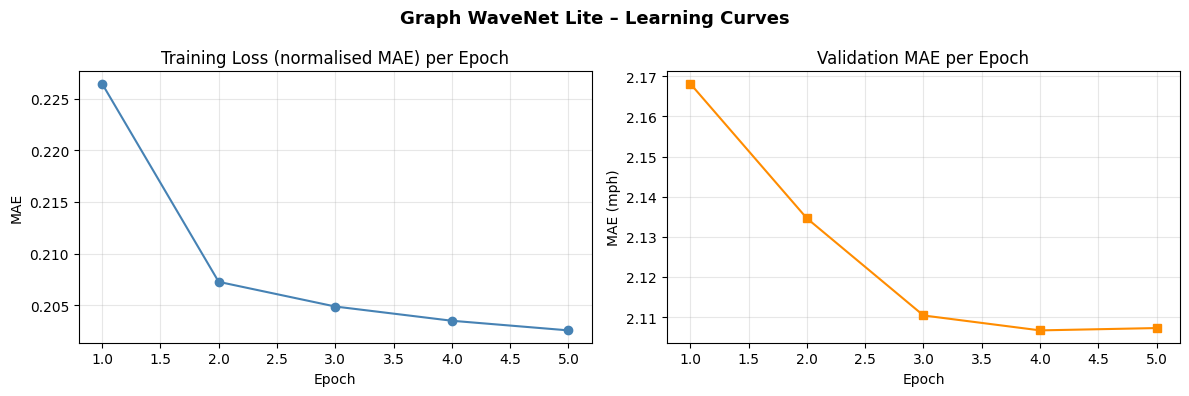

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS + 1), train_loss_history, marker='o', color='steelblue')
axes[0].set_title("Training Loss (normalised MAE) per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MAE")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), val_mae_history, marker='s', color='darkorange')
axes[1].set_title("Validation MAE per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (mph)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Graph WaveNet Lite – Learning Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Test Evaluation

In [13]:
test_mae, test_rmse, test_mape = run_eval(X_test, Y_test)
print(f"TEST | MAE {test_mae:.3f} mph | RMSE {test_rmse:.3f} mph | MAPE {test_mape:.4f}")

TEST | MAE 1.913 mph | RMSE 4.049 mph | MAPE 0.0434


## Visualisation 2: Adjacency Matrix Heatmap
Shows the **real edges** (road connections) as captured by the adjacency matrix. High weight = sensors are close / strongly connected on the road network.

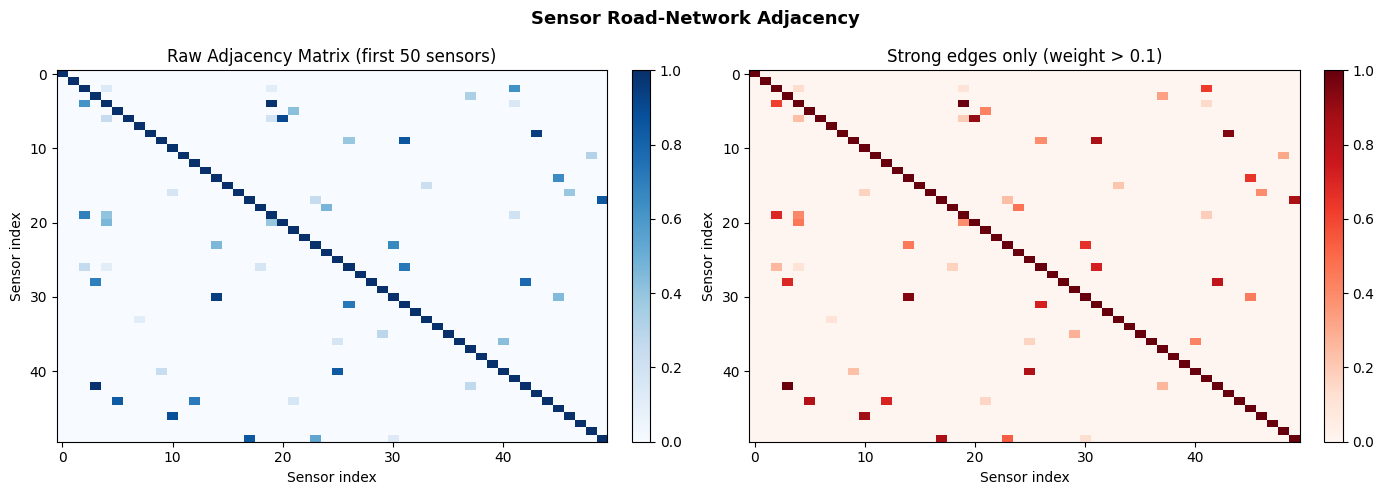

Total edges (weight > 0):   2694
Strong edges (weight > 0.1): 2694


In [14]:
# Show a submatrix for readability (first 50 sensors)
N_SHOW = min(50, adj_mx.shape[0])
sub    = adj_mx[:N_SHOW, :N_SHOW]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw adjacency
im0 = axes[0].imshow(sub, cmap='Blues', aspect='auto')
axes[0].set_title(f"Raw Adjacency Matrix (first {N_SHOW} sensors)")
axes[0].set_xlabel("Sensor index"); axes[0].set_ylabel("Sensor index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Thresholded – show only strong edges (>0.1)
sub_thresh = np.where(sub > 0.1, sub, 0.0)
im1 = axes[1].imshow(sub_thresh, cmap='Reds', aspect='auto')
axes[1].set_title(f"Strong edges only (weight > 0.1)")
axes[1].set_xlabel("Sensor index"); axes[1].set_ylabel("Sensor index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("Sensor Road-Network Adjacency", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total edges (weight > 0):   {int((adj_mx > 0).sum())}")
print(f"Strong edges (weight > 0.1): {int((adj_mx > 0.1).sum())}")

## Visualisation 3: Degree Distribution
How many road neighbours each sensor has.

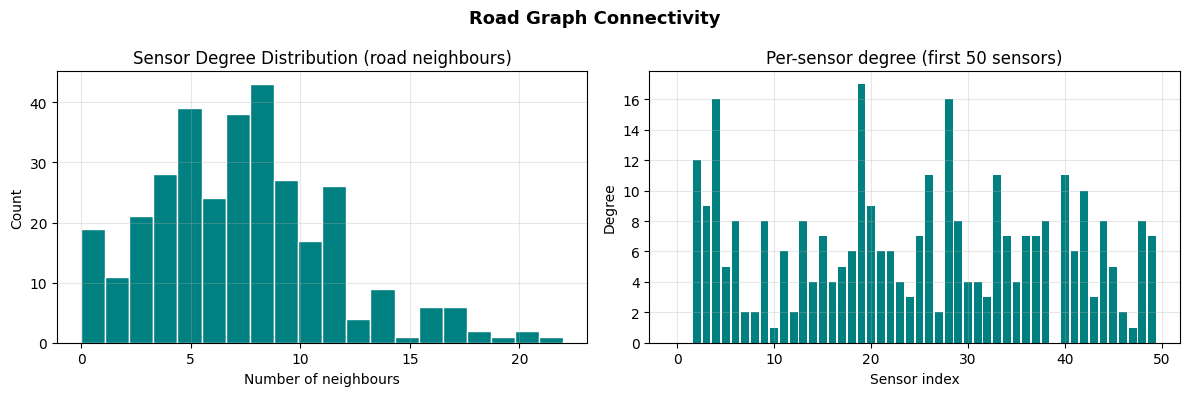

In [15]:
degrees = (adj_mx > 0).sum(axis=1).astype(int)
degrees_no_self = np.where(adj_mx > 0, 1, 0)
np.fill_diagonal(degrees_no_self, 0)
degrees_no_self = degrees_no_self.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(degrees_no_self, bins=20, color='teal', edgecolor='white')
axes[0].set_title("Sensor Degree Distribution (road neighbours)")
axes[0].set_xlabel("Number of neighbours"); axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(degrees_no_self[:50])), degrees_no_self[:50], color='teal')
axes[1].set_title("Per-sensor degree (first 50 sensors)")
axes[1].set_xlabel("Sensor index"); axes[1].set_ylabel("Degree")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Road Graph Connectivity", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Route Selection Helper

In [16]:
def neighbor_list(A, thr=0.0):
    n = A.shape[0]
    neigh = []
    for i in range(n):
        nbrs = np.where(A[i] > thr)[0]
        nbrs = nbrs[nbrs != i]   # remove self-loop
        neigh.append(nbrs)
    return neigh


def route_simple_path(neigh, start, length=20, seed=0):
    rng   = np.random.default_rng(seed)
    route = [start]
    visited = {start}
    cur = start
    for _ in range(length - 1):
        nbrs = [int(v) for v in neigh[cur] if int(v) not in visited]
        if not nbrs:
            break
        cur = int(rng.choice(nbrs))
        route.append(cur)
        visited.add(cur)
    return route


neigh      = neighbor_list(adj_mx, thr=0.0)
candidates = [i for i in range(len(neigh)) if len(neigh[i]) >= 2]
start      = int(np.random.choice(candidates))
route      = route_simple_path(neigh, start, length=20, seed=1)

print("Start sensor:", start, "| Degree:", len(neigh[start]))
print("Route length:", len(route))
print("Route:", route)

Start sensor: 192 | Degree: 5
Route length: 12
Route: [192, 88, 243, 244, 314, 170, 2, 226, 313, 50, 10, 115]


## Route Forecast

In [17]:
def route_forecast(sample_id, route_nodes):
    """
    Returns a 12-step forecast table for the route (mean speed across sensors).

    FIX: timestamps index was off; now correctly offset into the TEST portion.
    """
    route_nodes = [int(i) for i in route_nodes]
    model.eval()

    xb = torch.tensor(X_test[sample_id : sample_id + 1], device=DEVICE)
    yb = Y_test[sample_id : sample_id + 1]

    with torch.no_grad():
        pred_norm = model(xb, SUPPORTS).cpu().numpy()       # (1, 12, N, 1)

    pred = scaler.inverse_transform(pred_norm)[0, :, route_nodes, 0].mean(axis=1)  # (12,)
    true = scaler.inverse_transform(yb)[0, :, route_nodes, 0].mean(axis=1)         # (12,)
    abs_err = np.abs(pred - true)

    # Correct timestamp: test split starts at val_end; window starts INPUT_LEN steps in
    base_time = timestamps[val_end + INPUT_LEN + sample_id]
    times = [base_time + pd.Timedelta(minutes=STEP_MINUTES * k) for k in range(1, HORIZON + 1)]

    return pd.DataFrame({
        "time"      : times,
        "pred_speed" : pred,
        "true_speed" : true,
        "abs_error"  : abs_err,
    })


table = route_forecast(sample_id=500, route_nodes=route)
table

,time,pred_speed,true_speed,abs_error
0,2017-05-27 14:05:00,63.612049,63.725002,0.112953
1,2017-05-27 14:10:00,33.632908,34.875004,1.242096
2,2017-05-27 14:15:00,27.931383,22.091667,5.839716
3,2017-05-27 14:20:00,60.991688,61.091663,0.099976
4,2017-05-27 14:25:00,66.184326,66.616661,0.432335
5,2017-05-27 14:30:00,63.403889,65.000000,1.596111
6,2017-05-27 14:35:00,60.787640,58.875000,1.912640
7,2017-05-27 14:40:00,63.360081,61.358334,2.001747
8,2017-05-27 14:45:00,62.540195,62.475002,0.065193
9,2017-05-27 14:50:00,63.819942,64.383339,0.563396


## Visualisation 4: Route Forecast Plot

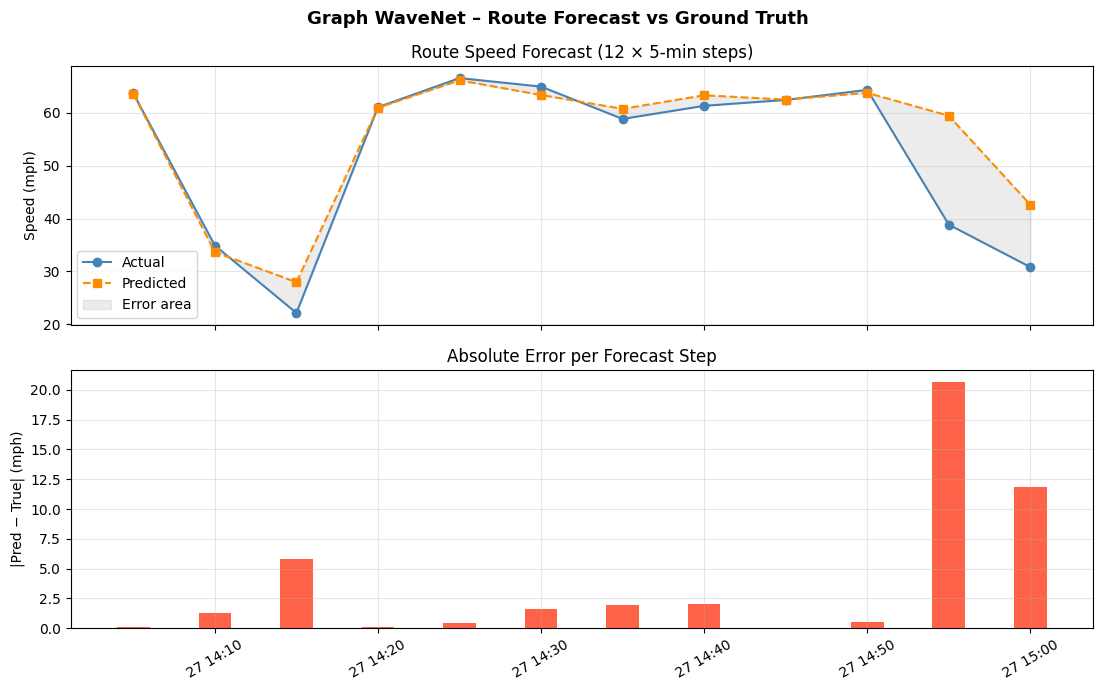

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Speed comparison
axes[0].plot(table["time"], table["true_speed"],  marker='o', label="Actual",    color='steelblue')
axes[0].plot(table["time"], table["pred_speed"],  marker='s', label="Predicted", color='darkorange', linestyle='--')
axes[0].fill_between(table["time"], table["true_speed"], table["pred_speed"],
                     alpha=0.15, color='gray', label="Error area")
axes[0].set_title("Route Speed Forecast (12 × 5-min steps)")
axes[0].set_ylabel("Speed (mph)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Error
axes[1].bar(table["time"], table["abs_error"], color='tomato', width=pd.Timedelta(minutes=2))
axes[1].set_title("Absolute Error per Forecast Step")
axes[1].set_ylabel("|Pred − True| (mph)")
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=30)
plt.suptitle("Graph WaveNet – Route Forecast vs Ground Truth", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualisation 5: Per-Horizon Error (all test samples)
Shows whether the model gets worse as we forecast further into the future (typical degradation).

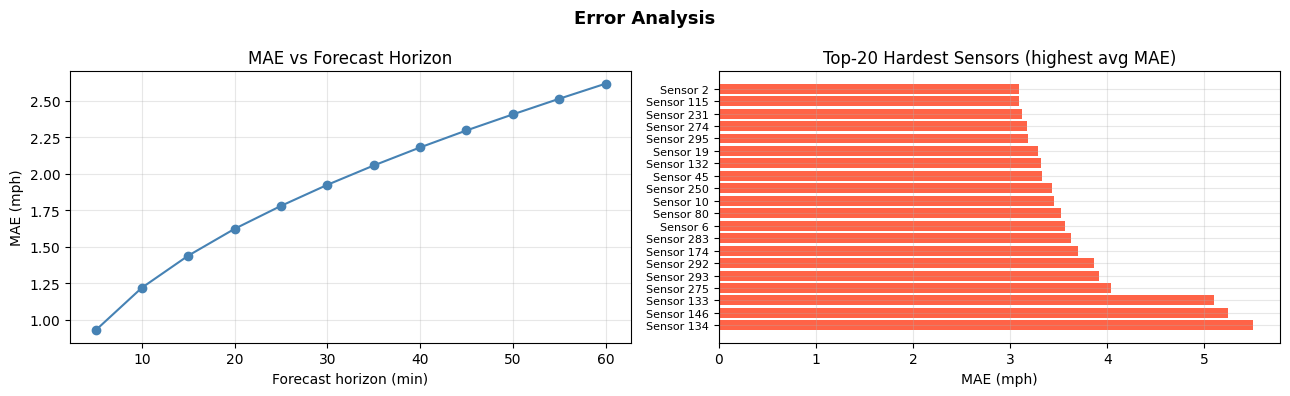


Per-step MAE (mph):
  t+ 5 min: 0.927
  t+10 min: 1.220
  t+15 min: 1.439
  t+20 min: 1.623
  t+25 min: 1.780
  t+30 min: 1.925
  t+35 min: 2.057
  t+40 min: 2.181
  t+45 min: 2.297
  t+50 min: 2.407
  t+55 min: 2.514
  t+60 min: 2.618


In [19]:
model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for xb, yb in batch_iter(X_test, Y_test, batch_size=BATCH_SIZE, shuffle=False):
        xb_t = torch.tensor(xb, device=DEVICE)
        pred = model(xb_t, SUPPORTS).cpu().numpy()           # (B, H, N, 1)
        all_preds.append(scaler.inverse_transform(pred))
        all_trues.append(scaler.inverse_transform(yb))

all_preds = np.concatenate(all_preds, axis=0)  # (S, H, N, 1)
all_trues = np.concatenate(all_trues, axis=0)

# Per-horizon MAE  (mask zero-speed readings)
mask = all_trues != 0.0
mae_per_step = []
for h in range(HORIZON):
    m = mask[:, h, :, 0]
    err = np.abs(all_preds[:, h, :, 0] - all_trues[:, h, :, 0])
    mae_per_step.append(err[m].mean() if m.any() else np.nan)

steps_min = [STEP_MINUTES * (k + 1) for k in range(HORIZON)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(steps_min, mae_per_step, marker='o', color='steelblue')
axes[0].set_title("MAE vs Forecast Horizon")
axes[0].set_xlabel("Forecast horizon (min)"); axes[0].set_ylabel("MAE (mph)")
axes[0].grid(True, alpha=0.3)

# Per-sensor mean MAE (which sensors are hardest to predict?)
sensor_mae = np.abs(all_preds[:, :, :, 0] - all_trues[:, :, :, 0])
sensor_mae[all_trues[:, :, :, 0] == 0] = np.nan
sensor_mae_mean = np.nanmean(sensor_mae, axis=(0, 1))   # (N,)

top_k = 20
order = np.argsort(sensor_mae_mean)[::-1][:top_k]
axes[1].barh(range(top_k), sensor_mae_mean[order], color='tomato')
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels([f"Sensor {i}" for i in order], fontsize=8)
axes[1].set_title(f"Top-{top_k} Hardest Sensors (highest avg MAE)")
axes[1].set_xlabel("MAE (mph)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Error Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPer-step MAE (mph):")
for i, v in enumerate(mae_per_step):
    print(f"  t+{(i+1)*STEP_MINUTES:2d} min: {v:.3f}")

## Visualisation 6: Sensor Road Graph (real edges only)
Draws only the edges that represent actual road connections (weight > threshold), so you see the real street topology.

Ego-graph (2-hop around sensor 192): 32 nodes, 137 edges


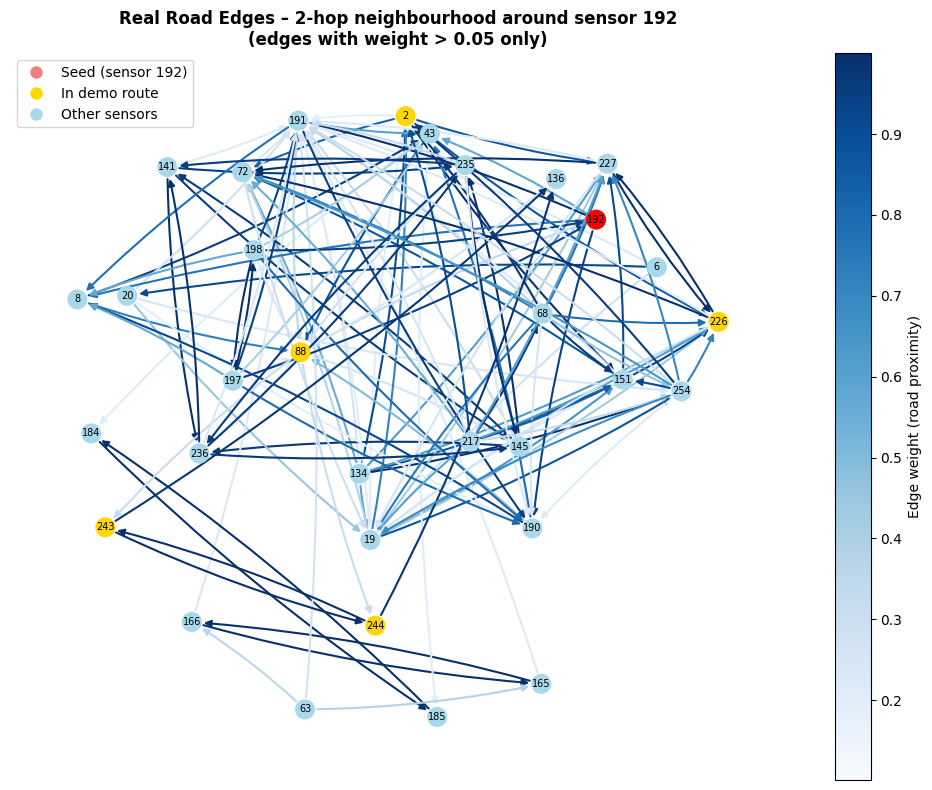

In [23]:
import networkx as nx

# Build graph with REAL edges only (weight > 0 means there is a road link)
EDGE_THRESHOLD = 0.05   # ignore very-weak / noisy entries

# For large graphs, visualising all nodes is unreadable — sample a local subgraph
SEED_NODE = route[0]    # start from the first sensor in our demo route
HOPS      = 2           # 2-hop neighbourhood

# Build full sparse graph first
G_full = nx.DiGraph()
rows, cols = np.where(adj_mx > EDGE_THRESHOLD)
for r, c in zip(rows, cols):
    if r != c:
        G_full.add_edge(int(r), int(c), weight=float(adj_mx[r, c]))

# Extract local ego-graph
ego = nx.ego_graph(G_full, SEED_NODE, radius=HOPS, undirected=True)
print(f"Ego-graph ({HOPS}-hop around sensor {SEED_NODE}): "
      f"{ego.number_of_nodes()} nodes, {ego.number_of_edges()} edges")

# Layout and draw
pos = nx.spring_layout(ego, seed=42, k=1.5)

edge_weights = np.array([ego[u][v]['weight'] for u, v in ego.edges()])
edge_colors  = plt.cm.Blues(edge_weights / edge_weights.max())

node_colors = ['red' if n == SEED_NODE
               else 'gold' if n in route
               else '#a8d8ea'
               for n in ego.nodes()]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(ego, pos, node_color=node_colors, node_size=180, ax=ax)
nx.draw_networkx_labels(ego, pos, font_size=7, ax=ax)
nx.draw_networkx_edges(ego, pos, edge_color=edge_colors, width=1.5,
                       arrowsize=10, ax=ax, connectionstyle='arc3,rad=0.05')

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral',  markersize=10, label=f'Seed (sensor {SEED_NODE})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gold',        markersize=10, label='In demo route'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#a8d8ea',     markersize=10, label='Other sensors'),
]
ax.legend(handles=legend_handles, loc='upper left')

sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(edge_weights.min(), edge_weights.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Edge weight (road proximity)')

ax.set_title(f"Real Road Edges – {HOPS}-hop neighbourhood around sensor {SEED_NODE}\n"
             f"(edges with weight > {EDGE_THRESHOLD} only)", fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## Travel Time Estimate

In [21]:
from math import radians, sin, cos, asin, sqrt

META_PATH = "/content/pems-bay-meta.h5"

def haversine_miles(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return 2 * asin(sqrt(a)) * 3956   # miles

meta = pd.read_hdf(META_PATH)
meta.index = meta.index.astype(int)
sensor_ids_int = np.array([int(s) for s in sensor_ids])

route_sensor_ids = sensor_ids_int[route]
meta_sub = meta.loc[meta.index.intersection(route_sensor_ids), ["Latitude", "Longitude"]]
coords   = [(meta_sub.loc[sid, "Latitude"], meta_sub.loc[sid, "Longitude"])
            for sid in route_sensor_ids if sid in meta_sub.index]

total_miles = sum(
    haversine_miles(coords[i][0], coords[i][1], coords[i+1][0], coords[i+1][1])
    for i in range(len(coords) - 1)
)

avg_speed_mph = float(table["pred_speed"].mean())
travel_time_min = (total_miles / avg_speed_mph) * 60 if avg_speed_mph > 0 else float('nan')

print(f"Route distance  : {total_miles:.3f} miles")
print(f"Avg pred speed  : {avg_speed_mph:.2f} mph")
print(f"Est. travel time: {travel_time_min:.2f} min")

Route distance  : 17.453 miles
Avg pred speed  : 55.70 mph
Est. travel time: 18.80 min


## Visualisation 7: Sensor Map (geo scatter)
Plots all sensors geographically. Colour = predicted mean speed over the 12-step horizon.

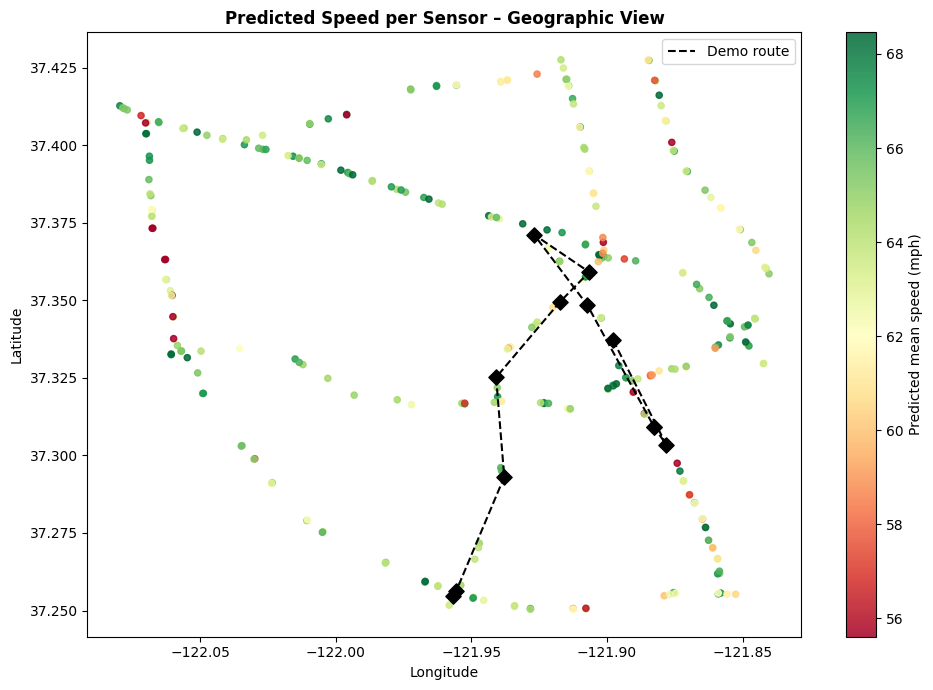

In [22]:
# Predicted mean speed per sensor (over the test sample used for route_forecast)
sample_id = 500
xb_vis = torch.tensor(X_test[sample_id : sample_id + 1], device=DEVICE)
with torch.no_grad():
    pred_vis = model(xb_vis, SUPPORTS).cpu().numpy()          # (1, 12, N, 1)

pred_vis_mean = scaler.inverse_transform(pred_vis)[0, :, :, 0].mean(axis=0)  # (N,)

# Get all sensor coords
meta_all = meta.reindex(sensor_ids_int)
lats_all = meta_all["Latitude"].values.astype(float)
lons_all = meta_all["Longitude"].values.astype(float)

# Mask sensors without coords
valid = ~(np.isnan(lats_all) | np.isnan(lons_all))

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(lons_all[valid], lats_all[valid],
                c=pred_vis_mean[valid], cmap='RdYlGn',
                vmin=np.nanpercentile(pred_vis_mean, 5),
                vmax=np.nanpercentile(pred_vis_mean, 95),
                s=20, alpha=0.85, zorder=3)

# Highlight route sensors
route_ids_in_meta = [sensor_ids_int[r] for r in route if sensor_ids_int[r] in meta_all.index]
rlats = [float(meta_all.loc[sid, "Latitude"]) for sid in route_ids_in_meta if not np.isnan(meta_all.loc[sid, "Latitude"])]
rlons = [float(meta_all.loc[sid, "Longitude"]) for sid in route_ids_in_meta if not np.isnan(meta_all.loc[sid, "Longitude"])]
ax.plot(rlons, rlats, 'k--', linewidth=1.5, zorder=4, label="Demo route")
ax.scatter(rlons, rlats, s=60, marker='D', color='black', zorder=5)

plt.colorbar(sc, ax=ax, label='Predicted mean speed (mph)')
ax.set_title("Predicted Speed per Sensor – Geographic View", fontsize=12, fontweight='bold')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend()
plt.tight_layout()
plt.show()